In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_erdos_renyi_graph(n, p, seed=None):
    rng = np.random.default_rng(seed)

    A = rng.random((n, n)) < p
    A = np.triu(A, 1)
    A = A + A.T

    return A.astype(int)

In [3]:
def permute_graph(A, seed=None):
    rng = np.random.default_rng(seed)

    n = A.shape[0]
    pi_true = rng.permutation(n)

    B = A[np.ix_(pi_true, pi_true)]

    return B, pi_true

In [4]:
def add_edge_flip_noise(B, epsilon, seed=None):
    rng = np.random.default_rng(seed)

    n = B.shape[0]
    noisy_B = B.copy()

    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < epsilon:
                noisy_B[i, j] = 1 - noisy_B[i, j]
                noisy_B[j, i] = noisy_B[i, j]

    return noisy_B

In [7]:
def edge_overlap_score(A, B, pi):
    n = A.shape[0]
    score = 0

    for i in range(n):
        for j in range(i + 1, n):
            score += A[i, j] * B[pi[i], pi[j]]

    return score

In [9]:
def alignment_accuracy(pi, pi_true):
    return np.mean(pi == pi_true)

In [11]:
def propose_swap(pi, rng):
    pi_new = pi.copy()
    n = len(pi)

    i, j = rng.choice(n, size=2, replace=False)

    pi_new[i], pi_new[j] = pi_new[j], pi_new[i]

    return pi_new

In [13]:
def simulated_annealing(A, B, pi_true=None, num_iters=5000, beta_start=0.01, beta_end=5.0, seed=None):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    # Start from a random permutation
    pi = rng.permutation(n)
    current_score = edge_overlap_score(A, B, pi)

    best_pi = pi.copy()
    best_score = current_score

    history = {
        "score": [],
        "best_score": [],
        "beta": [],
        "accuracy": [],
        "accepted": []
    }

    for t in range(num_iters):
        # Linear beta schedule
        beta = beta_start + (beta_end - beta_start) * t / (num_iters - 1)

        pi_new = propose_swap(pi, rng)
        new_score = edge_overlap_score(A, B, pi_new)

        delta = new_score - current_score

        if delta >= 0:
            accept = True
        else:
            accept_prob = np.exp(beta * delta)
            accept = rng.random() < accept_prob

        if accept:
            pi = pi_new
            current_score = new_score

        if current_score > best_score:
            best_pi = pi.copy()
            best_score = current_score

        history["score"].append(current_score)
        history["best_score"].append(best_score)
        history["beta"].append(beta)
        history["accepted"].append(accept)

        if pi_true is not None:
            history["accuracy"].append(alignment_accuracy(pi, pi_true))

    return best_pi, best_score, history

In [16]:
# ACTUAL PROJECT DATA GENERATED BY KOUROSH

In [17]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [19]:
manifest_path = Path("data/data/er_benchmark_v2_500/manifest.csv")

manifest = pd.read_csv(manifest_path)
manifest.head()

,filename,path,n,p,noise,noise_model,seed_id,generation_seed,density_A,density_B,...,num_edges_B,true_score,true_accuracy,degree_score,degree_accuracy,degree_cost,random_score_mean,random_score_std,random_accuracy_mean,random_accuracy_std
0,er_n30_p015_eps000_seed000_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,0,1315000,0.160920,0.160920,...,70,70.0,1.0,18.0,0.366667,0.0,11.52,2.927388,0.036667,0.033500
1,er_n30_p015_eps000_seed001_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,1,1315001,0.156322,0.156322,...,68,68.0,1.0,29.0,0.433333,0.0,10.58,2.530534,0.035333,0.029371
2,er_n30_p015_eps000_seed002_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,2,1315002,0.147126,0.147126,...,64,64.0,1.0,13.0,0.133333,0.0,9.70,2.247221,0.039333,0.036932
3,er_n30_p015_eps000_seed003_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,3,1315003,0.154023,0.154023,...,67,67.0,1.0,19.0,0.300000,0.0,11.10,2.773085,0.032667,0.028667
4,er_n30_p015_eps000_seed004_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,4,1315004,0.188506,0.188506,...,82,82.0,1.0,32.0,0.400000,0.0,16.34,3.283961,0.030667,0.035176


In [20]:
row = manifest[
    (manifest["n"] == 30) &
    (manifest["p"] == 0.15) &
    (manifest["noise"] == 0.0) &
    (manifest["seed_id"] == 0)
].iloc[0]

row

filename                          er_n30_p015_eps000_seed000_resample.npz
path                    data\er_benchmark_v2_500\er_n30_p015_eps000_se...
n                                                                      30
p                                                                    0.15
noise                                                                 0.0
noise_model                                                      resample
seed_id                                                                 0
generation_seed                                                   1315000
density_A                                                         0.16092
density_B                                                         0.16092
num_edges_A                                                            70
num_edges_B                                                            70
true_score                                                           70.0
true_accuracy                         

In [21]:
data_dir = manifest_path.parent
npz_path = data_dir / row["filename"]

data = np.load(npz_path, allow_pickle=True)

A = data["A"]
B = data["B"]
pi_true = data["pi_true"]

n = int(data["n"])
p = float(data["p"])
noise = float(data["noise"])

print("Loaded:", npz_path)
print("A shape:", A.shape)
print("B shape:", B.shape)
print("n:", n)
print("p:", p)
print("noise:", noise)
print("pi_true[:10]:", pi_true[:10])

Loaded: data\data\er_benchmark_v2_500\er_n30_p015_eps000_seed000_resample.npz
A shape: (30, 30)
B shape: (30, 30)
n: 30
p: 0.15
noise: 0.0
pi_true[:10]: [15 12 11 10  5 29  0 21 27 28]


In [22]:
rng = np.random.default_rng(0)
random_pi = rng.permutation(n)

print("True score from function:", edge_overlap_score(A, B, pi_true))
print("True score from manifest:", row["true_score"])
print("Random score:", edge_overlap_score(A, B, random_pi))
print("True accuracy:", alignment_accuracy(pi_true, pi_true))
print("Random accuracy:", alignment_accuracy(random_pi, pi_true))

True score from function: 70
True score from manifest: 70.0
Random score: 12
True accuracy: 1.0
Random accuracy: 0.03333333333333333


In [23]:
best_pi, best_score, history = simulated_annealing(
    A,
    B,
    pi_true=pi_true,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    seed=10
)

print("Best score found:", best_score)
print("True score:", edge_overlap_score(A, B, pi_true))
print("Best alignment accuracy:", alignment_accuracy(best_pi, pi_true))

Best score found: 41
True score: 70
Best alignment accuracy: 0.03333333333333333


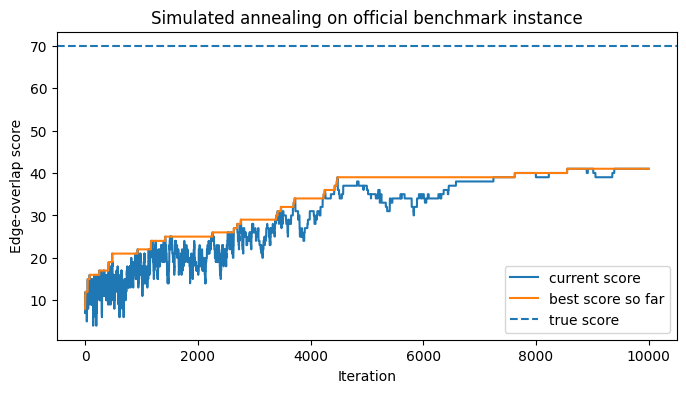

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history["score"], label="current score")
plt.plot(history["best_score"], label="best score so far")
plt.axhline(edge_overlap_score(A, B, pi_true), linestyle="--", label="true score")
plt.xlabel("Iteration")
plt.ylabel("Edge-overlap score")
plt.title("Simulated annealing on official benchmark instance")
plt.legend()
plt.show()

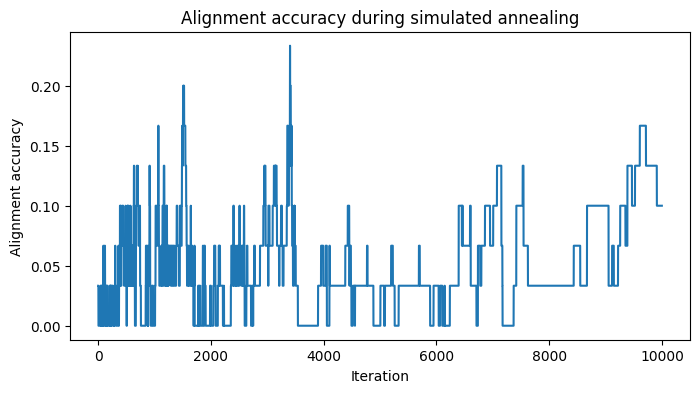

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(history["accuracy"])
plt.xlabel("Iteration")
plt.ylabel("Alignment accuracy")
plt.title("Alignment accuracy during simulated annealing")
plt.show()

In [25]:
def simulated_annealing(A, B, pi_true=None, num_iters=5000,
                        beta_start=0.01, beta_end=5.0,
                        seed=None, init_pi=None):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    if init_pi is None:
        pi = rng.permutation(n)
    else:
        pi = init_pi.copy()

    current_score = edge_overlap_score(A, B, pi)

    best_pi = pi.copy()
    best_score = current_score

    history = {
        "score": [],
        "best_score": [],
        "beta": [],
        "accuracy": [],
        "accepted": []
    }

    for t in range(num_iters):
        beta = beta_start + (beta_end - beta_start) * t / (num_iters - 1)

        pi_new = propose_swap(pi, rng)
        new_score = edge_overlap_score(A, B, pi_new)

        delta = new_score - current_score

        if delta >= 0:
            accept = True
        else:
            accept_prob = np.exp(beta * delta)
            accept = rng.random() < accept_prob

        if accept:
            pi = pi_new
            current_score = new_score

        if current_score > best_score:
            best_pi = pi.copy()
            best_score = current_score

        history["score"].append(current_score)
        history["best_score"].append(best_score)
        history["beta"].append(beta)
        history["accepted"].append(accept)

        if pi_true is not None:
            history["accuracy"].append(alignment_accuracy(pi, pi_true))

    return best_pi, best_score, history

In [26]:
best_pi_debug, best_score_debug, history_debug = simulated_annealing(
    A,
    B,
    pi_true=pi_true,
    num_iters=1000,
    beta_start=0.01,
    beta_end=5.0,
    seed=10,
    init_pi=pi_true
)

print("Starting from true permutation")
print("Best score found:", best_score_debug)
print("True score:", edge_overlap_score(A, B, pi_true))
print("Best accuracy:", alignment_accuracy(best_pi_debug, pi_true))

Starting from true permutation
Best score found: 70
True score: 70
Best accuracy: 1.0


In [27]:
def run_annealing_restarts(A, B, pi_true=None, num_restarts=20,
                           num_iters=10000, beta_start=0.01, beta_end=5.0,
                           seed=0):
    rng = np.random.default_rng(seed)

    best_overall_pi = None
    best_overall_score = -np.inf
    results = []

    for r in range(num_restarts):
        run_seed = rng.integers(1_000_000)

        best_pi, best_score, history = simulated_annealing(
            A,
            B,
            pi_true=pi_true,
            num_iters=num_iters,
            beta_start=beta_start,
            beta_end=beta_end,
            seed=run_seed
        )

        acc = None
        if pi_true is not None:
            acc = alignment_accuracy(best_pi, pi_true)

        results.append({
            "restart": r,
            "best_score": best_score,
            "accuracy": acc,
            "history": history
        })

        if best_score > best_overall_score:
            best_overall_score = best_score
            best_overall_pi = best_pi.copy()

    return best_overall_pi, best_overall_score, results

In [28]:
best_pi_restart, best_score_restart, restart_results = run_annealing_restarts(
    A,
    B,
    pi_true=pi_true,
    num_restarts=20,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    seed=123
)

print("Best restart score:", best_score_restart)
print("True score:", edge_overlap_score(A, B, pi_true))
print("Best restart accuracy:", alignment_accuracy(best_pi_restart, pi_true))

Best restart score: 70
True score: 70
Best restart accuracy: 1.0


In [29]:
restart_scores = [r["best_score"] for r in restart_results]
restart_accs = [r["accuracy"] for r in restart_results]

print("Scores:", restart_scores)
print("Accuracies:", restart_accs)
print("Mean score:", np.mean(restart_scores))
print("Max score:", np.max(restart_scores))
print("Mean accuracy:", np.mean(restart_accs))
print("Max accuracy:", np.max(restart_accs))

Scores: [np.int8(42), np.int8(43), np.int8(70), np.int8(44), np.int8(42), np.int8(70), np.int8(46), np.int8(41), np.int8(70), np.int8(42), np.int8(43), np.int8(42), np.int8(43), np.int8(42), np.int8(60), np.int8(70), np.int8(43), np.int8(44), np.int8(41), np.int8(70)]
Accuracies: [np.float64(0.2), np.float64(0.03333333333333333), np.float64(1.0), np.float64(0.1), np.float64(0.06666666666666667), np.float64(1.0), np.float64(0.03333333333333333), np.float64(0.06666666666666667), np.float64(1.0), np.float64(0.06666666666666667), np.float64(0.06666666666666667), np.float64(0.2), np.float64(0.03333333333333333), np.float64(0.06666666666666667), np.float64(0.7333333333333333), np.float64(1.0), np.float64(0.03333333333333333), np.float64(0.03333333333333333), np.float64(0.1), np.float64(1.0)]
Mean score: 50.4
Max score: 70
Mean accuracy: 0.3416666666666667
Max accuracy: 1.0


In [30]:
exact_recovery_rate = np.mean(np.array(restart_accs) == 1.0)
score_success_rate = np.mean(np.array(restart_scores) == row["true_score"])

print("Exact recovery rate:", exact_recovery_rate)
print("Reached true score rate:", score_success_rate)

Exact recovery rate: 0.25
Reached true score rate: 0.25


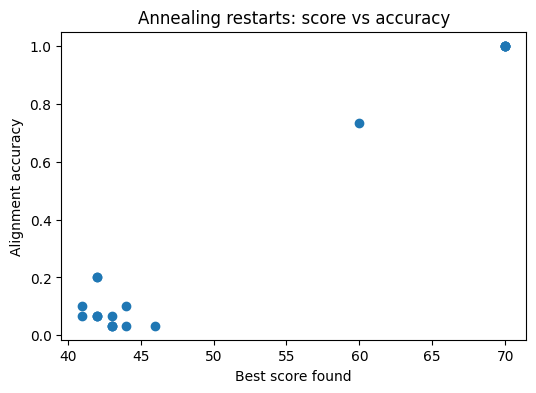

In [31]:
plt.figure(figsize=(6, 4))
plt.scatter(restart_scores, restart_accs)
plt.xlabel("Best score found")
plt.ylabel("Alignment accuracy")
plt.title("Annealing restarts: score vs accuracy")
plt.show()

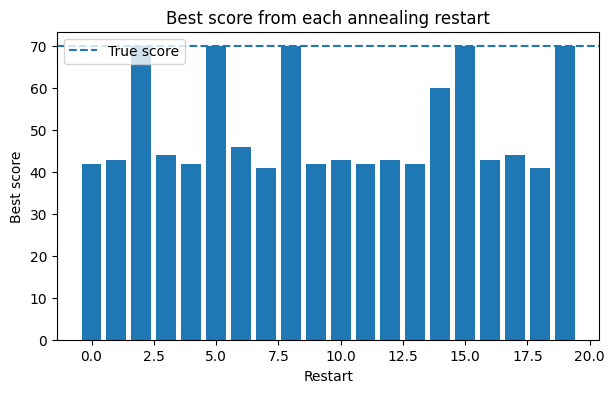

In [32]:
plt.figure(figsize=(7, 4))
plt.bar(range(len(restart_scores)), restart_scores)
plt.axhline(row["true_score"], linestyle="--", label="True score")
plt.xlabel("Restart")
plt.ylabel("Best score")
plt.title("Best score from each annealing restart")
plt.legend()
plt.show()

In [33]:
def evaluate_annealing_grid(
    manifest,
    data_dir,
    n_value=30,
    p_value=0.15,
    noise_values=(0.0, 0.05, 0.1, 0.2, 0.3),
    seed_ids=range(5),
    num_restarts=10,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    master_seed=123
):
    rng = np.random.default_rng(master_seed)
    rows = []

    for noise in noise_values:
        for seed_id in seed_ids:

            match = manifest[
                (manifest["n"] == n_value) &
                (np.isclose(manifest["p"], p_value)) &
                (np.isclose(manifest["noise"], noise)) &
                (manifest["seed_id"] == seed_id)
            ]

            if len(match) != 1:
                print(
                    f"Skipping n={n_value}, p={p_value}, "
                    f"noise={noise}, seed={seed_id}: found {len(match)} rows"
                )
                continue

            manifest_row = match.iloc[0]
            npz_path = data_dir / manifest_row["filename"]

            data = np.load(npz_path, allow_pickle=True)

            A = data["A"]
            B = data["B"]
            pi_true = data["pi_true"]

            true_score = edge_overlap_score(A, B, pi_true)

            best_pi, best_score, restart_results = run_annealing_restarts(
                A,
                B,
                pi_true=pi_true,
                num_restarts=num_restarts,
                num_iters=num_iters,
                beta_start=beta_start,
                beta_end=beta_end,
                seed=int(rng.integers(1_000_000_000))
            )

            restart_scores = np.array(
                [float(result["best_score"]) for result in restart_results]
            )
            restart_accuracies = np.array(
                [float(result["accuracy"]) for result in restart_results]
            )

            best_accuracy = alignment_accuracy(best_pi, pi_true)

            rows.append({
                "n": n_value,
                "p": p_value,
                "noise": noise,
                "seed_id": seed_id,
                "true_score": true_score,
                "best_score": float(best_score),
                "best_accuracy": float(best_accuracy),
                "mean_restart_score": restart_scores.mean(),
                "mean_restart_accuracy": restart_accuracies.mean(),
                "exact_recovery_rate": np.mean(restart_accuracies == 1.0),
                "true_score_hit_rate": np.mean(restart_scores == true_score),
                "num_restarts": num_restarts
            })

            print(
                f"noise={noise:.2f}, seed={seed_id:2d}, "
                f"best score={float(best_score):5.1f}/{true_score:5.1f}, "
                f"best accuracy={best_accuracy:.3f}, "
                f"exact rate={np.mean(restart_accuracies == 1.0):.2f}"
            )

    return pd.DataFrame(rows)

In [34]:
results = evaluate_annealing_grid(
    manifest=manifest,
    data_dir=manifest_path.parent,
    n_value=30,
    p_value=0.15,
    noise_values=[0.0, 0.05, 0.1, 0.2, 0.3],
    seed_ids=range(5),
    num_restarts=10,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    master_seed=123
)

results.head()

noise=0.00, seed= 0, best score= 70.0/ 70.0, best accuracy=1.000, exact rate=0.10
noise=0.00, seed= 1, best score= 68.0/ 68.0, best accuracy=1.000, exact rate=0.50
noise=0.00, seed= 2, best score= 64.0/ 64.0, best accuracy=1.000, exact rate=0.30
noise=0.00, seed= 3, best score= 67.0/ 67.0, best accuracy=1.000, exact rate=0.10
noise=0.00, seed= 4, best score= 82.0/ 82.0, best accuracy=1.000, exact rate=0.10
noise=0.05, seed= 0, best score= 58.0/ 58.0, best accuracy=1.000, exact rate=0.10
noise=0.05, seed= 1, best score= 44.0/ 52.0, best accuracy=0.733, exact rate=0.00
noise=0.05, seed= 2, best score= 51.0/ 54.0, best accuracy=0.933, exact rate=0.00
noise=0.05, seed= 3, best score= 43.0/ 64.0, best accuracy=0.133, exact rate=0.00
noise=0.05, seed= 4, best score= 46.0/ 65.0, best accuracy=0.300, exact rate=0.00
noise=0.10, seed= 0, best score= 55.0/ 59.0, best accuracy=0.933, exact rate=0.00
noise=0.10, seed= 1, best score= 68.0/ 68.0, best accuracy=1.000, exact rate=0.10
noise=0.10, seed

,n,p,noise,seed_id,true_score,best_score,best_accuracy,mean_restart_score,mean_restart_accuracy,exact_recovery_rate,true_score_hit_rate,num_restarts
0,30,0.15,0.0,0,70,70.0,1.0,46.6,0.210000,0.1,0.1,10
1,30,0.15,0.0,1,68,68.0,1.0,54.8,0.576667,0.5,0.5,10
2,30,0.15,0.0,2,64,64.0,1.0,48.6,0.420000,0.3,0.3,10
3,30,0.15,0.0,3,67,67.0,1.0,47.5,0.280000,0.1,0.1,10
4,30,0.15,0.0,4,82,82.0,1.0,55.8,0.183333,0.1,0.1,10


In [35]:
summary = (
    results
    .groupby("noise")
    .agg(
        mean_best_accuracy=("best_accuracy", "mean"),
        std_best_accuracy=("best_accuracy", "std"),
        mean_restart_accuracy=("mean_restart_accuracy", "mean"),
        mean_exact_recovery_rate=("exact_recovery_rate", "mean"),
        mean_true_score_hit_rate=("true_score_hit_rate", "mean"),
        mean_best_score=("best_score", "mean"),
        mean_true_score=("true_score", "mean")
    )
    .reset_index()
)

summary

,noise,mean_best_accuracy,std_best_accuracy,mean_restart_accuracy,mean_exact_recovery_rate,mean_true_score_hit_rate,mean_best_score,mean_true_score
0,0.00,1.000000,0.000000,0.334000,0.22,0.22,70.2,70.2
1,0.05,0.620000,0.385573,0.124667,0.02,0.02,48.4,58.6
2,0.10,0.706667,0.383985,0.214000,0.10,0.10,54.4,62.0
3,0.20,0.280000,0.408656,0.113333,0.04,0.04,44.8,52.8
4,0.30,0.140000,0.118790,0.052667,0.00,0.04,40.2,44.0


In [36]:
results = evaluate_annealing_grid(
    manifest=manifest,
    data_dir=manifest_path.parent,
    n_value=30,
    p_value=0.15,
    noise_values=[0.0, 0.05, 0.1, 0.2, 0.3],
    seed_ids=range(25),
    num_restarts=10,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    master_seed=123
)

results.head()

noise=0.00, seed= 0, best score= 70.0/ 70.0, best accuracy=1.000, exact rate=0.10
noise=0.00, seed= 1, best score= 68.0/ 68.0, best accuracy=1.000, exact rate=0.50
noise=0.00, seed= 2, best score= 64.0/ 64.0, best accuracy=1.000, exact rate=0.30
noise=0.00, seed= 3, best score= 67.0/ 67.0, best accuracy=1.000, exact rate=0.10
noise=0.00, seed= 4, best score= 82.0/ 82.0, best accuracy=1.000, exact rate=0.10
noise=0.00, seed= 5, best score= 44.0/ 69.0, best accuracy=0.100, exact rate=0.00
noise=0.00, seed= 6, best score= 74.0/ 74.0, best accuracy=1.000, exact rate=0.20
noise=0.00, seed= 7, best score= 39.0/ 60.0, best accuracy=0.133, exact rate=0.00
noise=0.00, seed= 8, best score= 46.0/ 72.0, best accuracy=0.267, exact rate=0.00
noise=0.00, seed= 9, best score= 80.0/ 80.0, best accuracy=1.000, exact rate=0.20
noise=0.00, seed=10, best score= 51.0/ 66.0, best accuracy=0.600, exact rate=0.00
noise=0.00, seed=11, best score= 73.0/ 73.0, best accuracy=1.000, exact rate=0.10
noise=0.00, seed

noise=0.30, seed= 0, best score= 38.0/ 43.0, best accuracy=0.033, exact rate=0.00
noise=0.30, seed= 1, best score= 43.0/ 51.0, best accuracy=0.100, exact rate=0.00
noise=0.30, seed= 2, best score= 40.0/ 44.0, best accuracy=0.033, exact rate=0.00
noise=0.30, seed= 3, best score= 36.0/ 35.0, best accuracy=0.100, exact rate=0.00
noise=0.30, seed= 4, best score= 42.0/ 47.0, best accuracy=0.100, exact rate=0.00
noise=0.30, seed= 5, best score= 43.0/ 50.0, best accuracy=0.067, exact rate=0.00
noise=0.30, seed= 6, best score= 44.0/ 47.0, best accuracy=0.300, exact rate=0.00
noise=0.30, seed= 7, best score= 36.0/ 40.0, best accuracy=0.133, exact rate=0.00
noise=0.30, seed= 8, best score= 40.0/ 43.0, best accuracy=0.033, exact rate=0.00
noise=0.30, seed= 9, best score= 43.0/ 47.0, best accuracy=0.267, exact rate=0.00
noise=0.30, seed=10, best score= 40.0/ 41.0, best accuracy=0.000, exact rate=0.00
noise=0.30, seed=11, best score= 42.0/ 55.0, best accuracy=0.000, exact rate=0.00
noise=0.30, seed

,n,p,noise,seed_id,true_score,best_score,best_accuracy,mean_restart_score,mean_restart_accuracy,exact_recovery_rate,true_score_hit_rate,num_restarts
0,30,0.15,0.0,0,70,70.0,1.0,46.6,0.210000,0.1,0.1,10
1,30,0.15,0.0,1,68,68.0,1.0,54.8,0.576667,0.5,0.5,10
2,30,0.15,0.0,2,64,64.0,1.0,48.6,0.420000,0.3,0.3,10
3,30,0.15,0.0,3,67,67.0,1.0,47.5,0.280000,0.1,0.1,10
4,30,0.15,0.0,4,82,82.0,1.0,55.8,0.183333,0.1,0.1,10


In [38]:
summary_25 = (
    results
    .groupby("noise")
    .agg(
        mean_best_accuracy=("best_accuracy", "mean"),
        std_best_accuracy=("best_accuracy", "std"),
        sem_best_accuracy=(
            "best_accuracy",
            lambda x: x.std(ddof=1) / np.sqrt(len(x))
        ),
        mean_restart_accuracy=("mean_restart_accuracy", "mean"),
        mean_exact_recovery_rate=("exact_recovery_rate", "mean"),
        mean_true_score_hit_rate=("true_score_hit_rate", "mean"),
        mean_best_score=("best_score", "mean"),
        mean_true_score=("true_score", "mean")
    )
    .reset_index()
)

summary_25

,noise,mean_best_accuracy,std_best_accuracy,sem_best_accuracy,mean_restart_accuracy,mean_exact_recovery_rate,mean_true_score_hit_rate,mean_best_score,mean_true_score
0,0.00,0.805333,0.324134,0.064827,0.233600,0.116,0.128,61.96,67.60
1,0.05,0.553333,0.390986,0.078197,0.177467,0.072,0.072,51.84,63.00
2,0.10,0.660000,0.365655,0.073131,0.157200,0.036,0.036,52.00,59.44
3,0.20,0.264000,0.353674,0.070735,0.091067,0.008,0.008,45.56,53.96
4,0.30,0.122667,0.198074,0.039615,0.064533,0.004,0.016,42.80,47.92


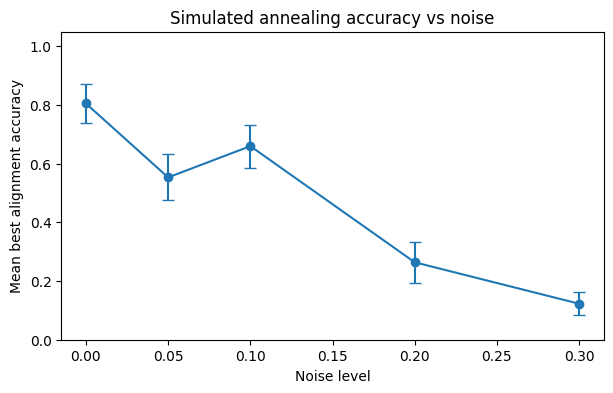

In [39]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    summary_25["noise"],
    summary_25["mean_best_accuracy"],
    yerr=summary_25["sem_best_accuracy"],
    marker="o",
    capsize=4
)

plt.xlabel("Noise level")
plt.ylabel("Mean best alignment accuracy")
plt.title("Simulated annealing accuracy vs noise")
plt.ylim(0, 1.05)
plt.show()

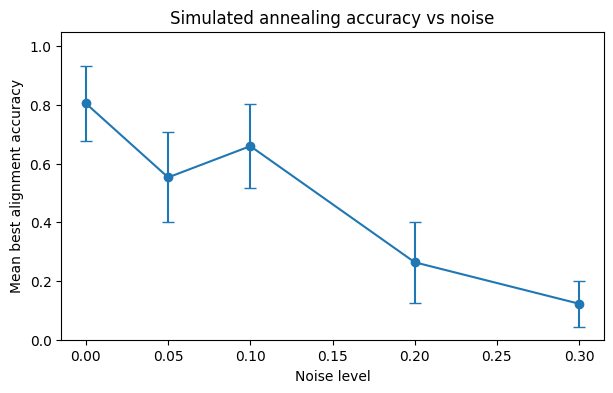

In [40]:
summary_25["ci95"] = 1.96 * summary_25["sem_best_accuracy"]

plt.figure(figsize=(7, 4))

plt.errorbar(
    summary_25["noise"],
    summary_25["mean_best_accuracy"],
    yerr=summary_25["ci95"],
    marker="o",
    capsize=4
)

plt.xlabel("Noise level")
plt.ylabel("Mean best alignment accuracy")
plt.title("Simulated annealing accuracy vs noise")
plt.ylim(0, 1.05)
plt.show()

In [42]:
results.to_csv("annealing_results_n30_p015_25seeds.csv", index=False)
summary_25.to_csv("annealing_summary_n30_p015_25seeds.csv", index=False)

In [43]:
def evaluate_restart_sweep(
    manifest,
    data_dir,
    n_value=30,
    p_value=0.15,
    noise_values=(0.0, 0.05, 0.1, 0.2, 0.3),
    seed_ids=range(25),
    restart_values=(1, 5, 10, 20, 50),
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    master_seed=123
):
    rng = np.random.default_rng(master_seed)
    rows = []

    for noise in noise_values:
        for seed_id in seed_ids:

            match = manifest[
                (manifest["n"] == n_value) &
                (np.isclose(manifest["p"], p_value)) &
                (np.isclose(manifest["noise"], noise)) &
                (manifest["seed_id"] == seed_id)
            ]

            if len(match) != 1:
                print(
                    f"Skipping n={n_value}, p={p_value}, "
                    f"noise={noise}, seed={seed_id}: found {len(match)} rows"
                )
                continue

            manifest_row = match.iloc[0]
            npz_path = data_dir / manifest_row["filename"]

            data = np.load(npz_path, allow_pickle=True)

            A = data["A"]
            B = data["B"]
            pi_true = data["pi_true"]

            true_score = edge_overlap_score(A, B, pi_true)

            # Run the maximum number of restarts once.
            max_restarts = max(restart_values)

            _, _, restart_results = run_annealing_restarts(
                A,
                B,
                pi_true=pi_true,
                num_restarts=max_restarts,
                num_iters=num_iters,
                beta_start=beta_start,
                beta_end=beta_end,
                seed=int(rng.integers(1_000_000_000))
            )

            restart_scores = np.array(
                [float(result["best_score"]) for result in restart_results]
            )
            restart_accuracies = np.array(
                [float(result["accuracy"]) for result in restart_results]
            )

            for R in restart_values:
                scores_R = restart_scores[:R]
                accs_R = restart_accuracies[:R]

                best_idx = np.argmax(scores_R)

                rows.append({
                    "n": n_value,
                    "p": p_value,
                    "noise": noise,
                    "seed_id": seed_id,
                    "num_restarts": R,
                    "true_score": float(true_score),
                    "best_score": float(scores_R[best_idx]),
                    "best_accuracy": float(accs_R[best_idx]),
                    "mean_restart_score": float(scores_R.mean()),
                    "mean_restart_accuracy": float(accs_R.mean()),
                    "exact_recovery_any": float(np.any(accs_R == 1.0)),
                    "true_score_hit_any": float(np.any(scores_R == true_score)),
                    "single_restart_accuracy": float(accs_R[0]),
                    "single_restart_score": float(scores_R[0])
                })

            print(
                f"finished noise={noise:.2f}, seed={seed_id:2d}, "
                f"best of {max_restarts} acc={restart_accuracies[np.argmax(restart_scores)]:.3f}, "
                f"best score={restart_scores.max():.1f}/{true_score:.1f}"
            )

    return pd.DataFrame(rows)

In [44]:
restart_sweep = evaluate_restart_sweep(
    manifest=manifest,
    data_dir=manifest_path.parent,
    n_value=30,
    p_value=0.15,
    noise_values=[0.0, 0.05, 0.1, 0.2, 0.3],
    seed_ids=range(25),
    restart_values=[1, 5, 10, 20, 50],
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    master_seed=456
)

restart_sweep.head()

finished noise=0.00, seed= 0, best of 50 acc=1.000, best score=70.0/70.0
finished noise=0.00, seed= 1, best of 50 acc=1.000, best score=68.0/68.0
finished noise=0.00, seed= 2, best of 50 acc=1.000, best score=64.0/64.0
finished noise=0.00, seed= 3, best of 50 acc=1.000, best score=67.0/67.0
finished noise=0.00, seed= 4, best of 50 acc=1.000, best score=82.0/82.0
finished noise=0.00, seed= 5, best of 50 acc=1.000, best score=69.0/69.0
finished noise=0.00, seed= 6, best of 50 acc=1.000, best score=74.0/74.0
finished noise=0.00, seed= 7, best of 50 acc=1.000, best score=60.0/60.0
finished noise=0.00, seed= 8, best of 50 acc=1.000, best score=72.0/72.0
finished noise=0.00, seed= 9, best of 50 acc=1.000, best score=80.0/80.0
finished noise=0.00, seed=10, best of 50 acc=1.000, best score=66.0/66.0
finished noise=0.00, seed=11, best of 50 acc=1.000, best score=73.0/73.0
finished noise=0.00, seed=12, best of 50 acc=1.000, best score=60.0/60.0
finished noise=0.00, seed=13, best of 50 acc=1.000,

finished noise=0.30, seed=13, best of 50 acc=1.000, best score=70.0/70.0
finished noise=0.30, seed=14, best of 50 acc=0.933, best score=57.0/57.0
finished noise=0.30, seed=15, best of 50 acc=0.000, best score=40.0/44.0
finished noise=0.30, seed=16, best of 50 acc=0.033, best score=44.0/44.0
finished noise=0.30, seed=17, best of 50 acc=0.000, best score=45.0/53.0
finished noise=0.30, seed=18, best of 50 acc=0.067, best score=50.0/55.0
finished noise=0.30, seed=19, best of 50 acc=0.267, best score=45.0/45.0
finished noise=0.30, seed=20, best of 50 acc=0.033, best score=43.0/47.0
finished noise=0.30, seed=21, best of 50 acc=0.067, best score=46.0/54.0
finished noise=0.30, seed=22, best of 50 acc=0.067, best score=44.0/45.0
finished noise=0.30, seed=23, best of 50 acc=0.033, best score=44.0/46.0
finished noise=0.30, seed=24, best of 50 acc=0.000, best score=40.0/43.0


,n,p,noise,seed_id,num_restarts,true_score,best_score,best_accuracy,mean_restart_score,mean_restart_accuracy,exact_recovery_any,true_score_hit_any,single_restart_accuracy,single_restart_score
0,30,0.15,0.0,0,1,70.0,70.0,1.0,70.00,1.000000,1.0,1.0,1.0,70.0
1,30,0.15,0.0,0,5,70.0,70.0,1.0,58.40,0.580000,1.0,1.0,1.0,70.0
2,30,0.15,0.0,0,10,70.0,70.0,1.0,51.10,0.366667,1.0,1.0,1.0,70.0
3,30,0.15,0.0,0,20,70.0,70.0,1.0,49.25,0.291667,1.0,1.0,1.0,70.0
4,30,0.15,0.0,0,50,70.0,70.0,1.0,48.08,0.280000,1.0,1.0,1.0,70.0


In [45]:
restart_sweep.to_csv("annealing_restart_sweep_n30_p015.csv", index=False)

In [46]:
restart_summary = (
    restart_sweep
    .groupby(["noise", "num_restarts"])
    .agg(
        mean_best_accuracy=("best_accuracy", "mean"),
        std_best_accuracy=("best_accuracy", "std"),
        sem_best_accuracy=(
            "best_accuracy",
            lambda x: x.std(ddof=1) / np.sqrt(len(x))
        ),
        mean_best_score=("best_score", "mean"),
        mean_true_score=("true_score", "mean"),
        exact_recovery_probability=("exact_recovery_any", "mean"),
        true_score_hit_probability=("true_score_hit_any", "mean"),
        mean_single_restart_accuracy=("single_restart_accuracy", "mean")
    )
    .reset_index()
)

restart_summary

,noise,num_restarts,mean_best_accuracy,std_best_accuracy,sem_best_accuracy,mean_best_score,mean_true_score,exact_recovery_probability,true_score_hit_probability,mean_single_restart_accuracy
0,0.00,1,0.269333,0.385852,0.077170,46.68,67.60,0.12,0.12,0.269333
1,0.00,5,0.653333,0.404718,0.080944,57.52,67.60,0.44,0.48,0.269333
2,0.00,10,0.816000,0.318579,0.063716,61.92,67.60,0.64,0.64,0.269333
3,0.00,20,0.961333,0.107013,0.021403,65.48,67.60,0.84,0.84,0.269333
4,0.00,50,0.997333,0.013333,0.002667,67.60,67.60,1.00,1.00,0.269333
5,0.05,1,0.165333,0.261137,0.052227,42.96,63.00,0.04,0.04,0.165333
6,0.05,5,0.464000,0.404365,0.080873,50.44,63.00,0.28,0.28,0.165333
7,0.05,10,0.652000,0.383946,0.076789,54.80,63.00,0.44,0.44,0.165333
8,0.05,20,0.764000,0.346667,0.069333,57.52,63.00,0.60,0.60,0.165333
9,0.05,50,0.936000,0.226675,0.045335,61.88,63.00,0.92,0.92,0.165333


In [47]:
restart_summary.to_csv("annealing_restart_sweep_summary_n30_p015.csv", index=False)

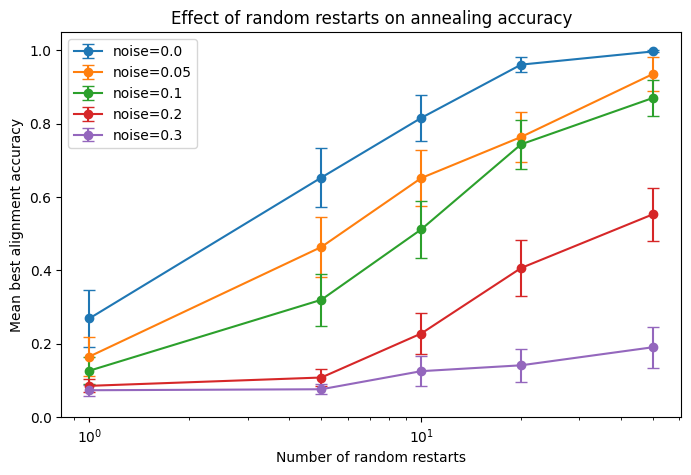

In [48]:
plt.figure(figsize=(8, 5))

for noise in sorted(restart_summary["noise"].unique()):
    sub = restart_summary[restart_summary["noise"] == noise]

    plt.errorbar(
        sub["num_restarts"],
        sub["mean_best_accuracy"],
        yerr=sub["sem_best_accuracy"],
        marker="o",
        capsize=4,
        label=f"noise={noise}"
    )

plt.xscale("log")
plt.xlabel("Number of random restarts")
plt.ylabel("Mean best alignment accuracy")
plt.title("Effect of random restarts on annealing accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

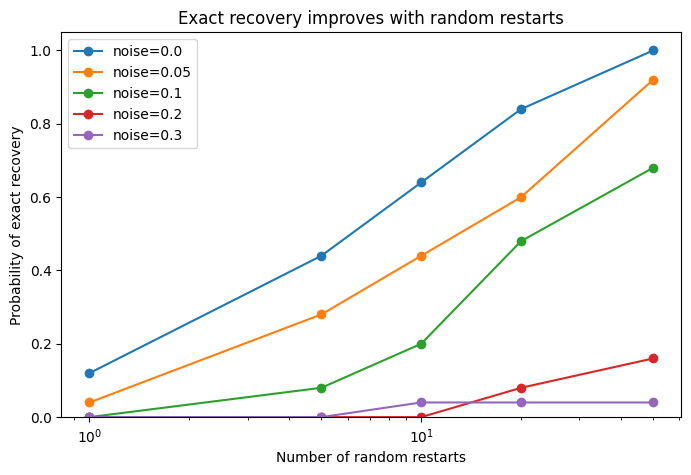

In [49]:
plt.figure(figsize=(8, 5))

for noise in sorted(restart_summary["noise"].unique()):
    sub = restart_summary[restart_summary["noise"] == noise]

    plt.plot(
        sub["num_restarts"],
        sub["exact_recovery_probability"],
        marker="o",
        label=f"noise={noise}"
    )

plt.xscale("log")
plt.xlabel("Number of random restarts")
plt.ylabel("Probability of exact recovery")
plt.title("Exact recovery improves with random restarts")
plt.ylim(0, 1.05)
plt.legend()
plt.show()